In [2]:
#Import necessary libraries
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

#Import functions from other files
from scripts.data_loader import DataLoader
from scripts.optimizer import mean_variance_model

In [3]:
#Load data
loader = DataLoader()

#Optimize portfolio
model, w = mean_variance_model(
    expected_returns=loader.expected_returns,
    covariance_matrix=loader.covariance_matrix,
    max_weight=0.10,
    risk_aversion=5.0
)

model.optimize()

weights = [w[i].X for i in range(len(loader.expected_returns))]

Set parameter Username
Set parameter LicenseID to value 2822105
Academic license - for non-commercial use only - expires 2027-05-14
Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (mac64[arm] - Darwin 25.5.0 25F71)

CPU model: Apple M2
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 1 rows, 323 columns and 323 nonzeros (Max)
Model fingerprint: 0x3bde84a2
Model has 323 linear objective coefficients
Model has 52326 quadratic objective terms
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [2e-04, 2e-03]
  QObjective range [3e-04, 2e-02]
  Bounds range     [1e-01, 1e-01]
  RHS range        [1e+00, 1e+00]

Presolve time: 0.01s
Presolved: 1 rows, 323 columns, 323 nonzeros
Presolved model has 52326 quadratic objective terms
Ordering time: 0.00s

Barrier statistics:
 Free vars  : 322
 AA' NZ     : 5.200e+04
 Factor NZ  : 5.233e+04 (roughly 1 MB of memory)
 Factor Ops : 1.128e+07 (less than 1 second per iteration)


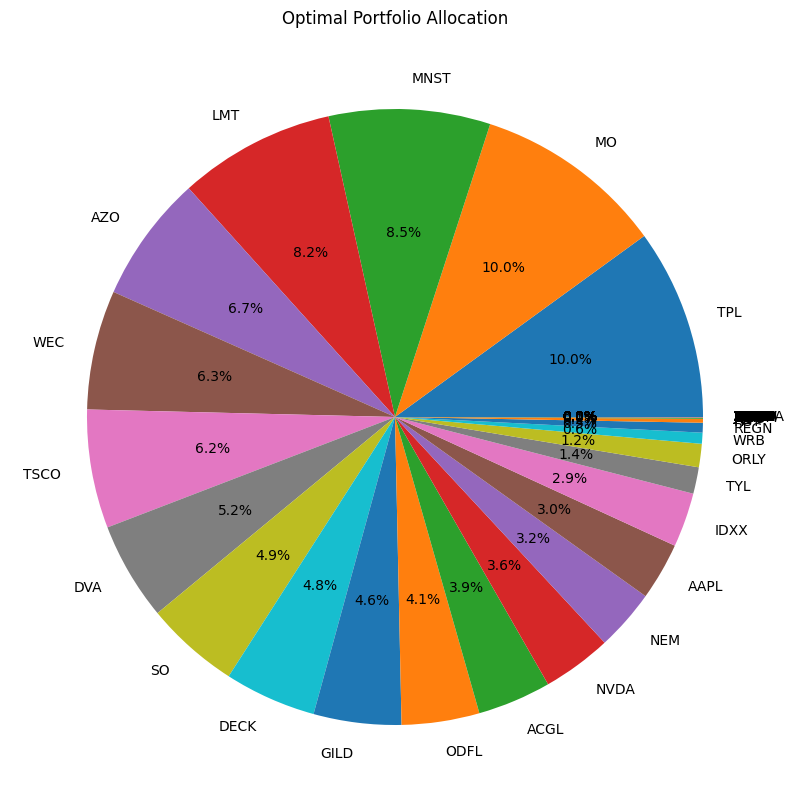

In [4]:
#Explore data
portfolio = pd.DataFrame({
    "Ticker": loader.tickers,
    "Weight": weights
})

portfolio = portfolio.sort_values(
    by="Weight",
    ascending=False
)

plt.figure(figsize=(10, 10))

plt.pie(
    portfolio["Weight"],
    labels=portfolio["Ticker"],
    autopct="%1.1f%%"
)

plt.title("Optimal Portfolio Allocation")

plt.show()

In [5]:
# Calculate expected yearly return of the portfolio
sum(
    w * r for w, r in zip(weights, loader.expected_returns)
)*252*100

np.float64(26.846022212120435)